# Word Prediction Using a Neural Language Model

**Student ID:** 2025AA05072  
**Assignment:** NLP — Neural Language Model for Word Prediction

---

## Objective
Implement a complete word-prediction pipeline using the Penn Treebank dataset:
- Preprocess text and build a vocabulary
- Create sliding-window sequences as model input
- Design and train an LSTM-based word predictor
- Evaluate using Perplexity (PPL)
- Generate top-k next word predictions

## Task 1: Setup & Imports (Virtual Lab)

**Observation:** All implementation is carried out in a Jupyter Notebook environment (Virtual Lab / local Jupyter). The following cell installs and imports all required libraries. PyTorch is used as the deep learning framework, with MPS (Apple Silicon) acceleration where available.

In [1]:
import os
import math
import random
import urllib.request
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device: use MPS (Apple Silicon) if available, else CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device selected : {device}")

PyTorch version : 2.8.0
Device selected : mps


## Task 2: Data Preprocessing & Vocabulary Building

### 2a. Download the Penn Treebank (PTB) Dataset

The Penn Treebank language-modeling splits (train / valid / test) are downloaded from the standard Wojzaremba LSTM repository — the same canonical splits referenced by `torchtext.datasets.PennTreebank`.

In [2]:
DATA_DIR = "ptb_data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/"
FILES = {
    "train": "ptb.train.txt",
    "valid": "ptb.valid.txt",
    "test":  "ptb.test.txt",
}

for split, fname in FILES.items():
    dest = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...", end=" ")
        urllib.request.urlretrieve(BASE_URL + fname, dest)
        print("done")
    else:
        print(f"{fname} already present")

for split, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    with open(path) as f:
        lines = f.readlines()
    print(f"{split:5s}: {len(lines):5d} lines, first tokens: {lines[0].split()[:8]}")

ptb.train.txt already present
ptb.valid.txt already present
ptb.test.txt already present
train: 42068 lines, first tokens: ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano']
valid:  3370 lines, first tokens: ['consumers', 'may', 'want', 'to', 'move', 'their', 'telephones', 'a']
test :  3761 lines, first tokens: ['no', 'it', 'was', "n't", 'black', 'monday']


### 2b. Tokenisation

Each line in the PTB file represents one sentence.
- Convert to **lowercase**
- Split on whitespace
- Append `<eos>` at the end of every sentence to mark sentence boundaries

**Inference:** Lowercasing reduces vocabulary sparsity (e.g., "The" and "the" map to the same token). `<eos>` tokens let the model learn sentence-boundary transitions, which is standard practice for LM training on PTB.

In [3]:
def read_and_tokenize(filepath):
    """Read file, lowercase, tokenize words, append <eos> per sentence."""
    tokens = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip().lower()
            if line:
                tokens.extend(line.split())
                tokens.append('<eos>')
    return tokens

train_tokens = read_and_tokenize(os.path.join(DATA_DIR, FILES['train']))
valid_tokens = read_and_tokenize(os.path.join(DATA_DIR, FILES['valid']))
test_tokens  = read_and_tokenize(os.path.join(DATA_DIR, FILES['test']))

print(f"Train tokens : {len(train_tokens):,}")
print(f"Valid tokens : {len(valid_tokens):,}")
print(f"Test  tokens : {len(test_tokens):,}")
print(f"Sample (train[0:15]): {train_tokens[:15]}")

Train tokens : 929,589
Valid tokens : 73,760
Test  tokens : 82,430
Sample (train[0:15]): ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec', 'ipo', 'kia', 'memotec', 'mlx', 'nahb']


### 2c. Vocabulary Building

- Vocabulary is restricted to the **top 10,000 most frequent** words from the training corpus.
- Two special tokens are prepended:
  - `<pad>` (index 0) — padding token
  - `<unk>` (index 1) — out-of-vocabulary words

**Inference:** Capping vocabulary at 10,000 removes rare words that add noise and bloat the embedding matrix. OOV words are mapped to `<unk>` so the model generalises to unseen vocabulary at inference time.

In [4]:
MAX_VOCAB = 10_000

def build_vocabulary(tokens, max_vocab=MAX_VOCAB):
    """Build word<->id mappings from the top-max_vocab frequent words."""
    counter = Counter(tokens)
    most_common = counter.most_common(max_vocab)

    # Reserve index 0 for <pad>, 1 for <unk>
    word_to_id = {'<pad>': 0, '<unk>': 1}
    id_to_word = {0: '<pad>', 1: '<unk>'}

    for word, _ in most_common:
        if word not in word_to_id:
            idx = len(word_to_id)
            word_to_id[word] = idx
            id_to_word[idx] = word

    return word_to_id, id_to_word

word_to_id, id_to_word = build_vocabulary(train_tokens)

VOCAB_SIZE = len(word_to_id)
PAD_IDX    = word_to_id['<pad>']
UNK_IDX    = word_to_id['<unk>']

print(f"Total vocabulary size (incl. special tokens): {VOCAB_SIZE}")
print(f"PAD index: {PAD_IDX}  |  UNK index: {UNK_IDX}")
print(f"Sample entries — word_to_id: { {k: word_to_id[k] for k in list(word_to_id)[:8]} }")

Total vocabulary size (incl. special tokens): 10001
PAD index: 0  |  UNK index: 1
Sample entries — word_to_id: {'<pad>': 0, '<unk>': 1, 'the': 2, '<eos>': 3, 'n': 4, 'of': 5, 'to': 6, 'a': 7}


### 2d. Encoding Tokens to Integer IDs

In [5]:
def encode_tokens(tokens, word_to_id):
    """Map each token to its integer ID; unknown tokens → UNK_IDX."""
    unk = word_to_id['<unk>']
    return [word_to_id.get(t, unk) for t in tokens]

train_ids = encode_tokens(train_tokens, word_to_id)
valid_ids = encode_tokens(valid_tokens, word_to_id)
test_ids  = encode_tokens(test_tokens,  word_to_id)

unk_count = sum(1 for i in valid_ids if i == UNK_IDX)
print(f"Valid OOV rate: {unk_count}/{len(valid_ids)} = {100*unk_count/len(valid_ids):.2f}%")
print(f"Encoded train sample: {train_ids[:10]}")
print(f"Decoded back        : {[id_to_word[i] for i in train_ids[:10]]}")

Valid OOV rate: 3485/73760 = 4.72%
Encoded train sample: [9971, 9972, 9973, 9974, 9975, 9976, 9977, 9978, 9979, 9980]
Decoded back        : ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec']


### 2e. Sliding Window Function

A sliding window of length **N = 30** generates (input, target) pairs:
- Input **X**: token IDs at positions `[i : i+N]`
- Target **y**: token ID at position `i+N`

**Example (N=3):**
Sentence "the cat sat on the mat" →
- X: [the, cat, sat] → y: on
- X: [cat, sat, on]  → y: the

A **stride of 5** is used for the training split to reduce dataset size from ~930K to ~186K samples, keeping training time tractable while preserving sufficient diversity. Validation and test use stride=1 (all windows) for accurate evaluation.

**Inference:** The sliding window transforms the sequential token stream into supervised (X, y) pairs suitable for batch training. N=30 captures enough context for the LSTM to learn meaningful long-range word dependencies.

In [6]:
SEQ_LEN = 30   # Context window length N
STRIDE  = 5    # Step size for training windows (stride=1 for valid/test)

def create_sliding_windows(token_ids, seq_len, stride=1):
    """
    Returns (X, y) where:
      X[i] = token_ids[i*stride : i*stride + seq_len]  (context)
      y[i] = token_ids[i*stride + seq_len]              (next word target)
    """
    X, y = [], []
    for i in range(0, len(token_ids) - seq_len, stride):
        X.append(token_ids[i : i + seq_len])
        y.append(token_ids[i + seq_len])
    return X, y

train_X, train_y = create_sliding_windows(train_ids, SEQ_LEN, stride=STRIDE)
valid_X, valid_y = create_sliding_windows(valid_ids, SEQ_LEN, stride=1)
test_X,  test_y  = create_sliding_windows(test_ids,  SEQ_LEN, stride=1)

print(f"Sliding window examples (SEQ_LEN={SEQ_LEN}, stride={STRIDE} for train):")
print(f"  Train samples: {len(train_X):,}")
print(f"  Valid samples: {len(valid_X):,}")
print(f"  Test  samples: {len(test_X):,}")
print()
print("Example pair (decoded):")
print(f"  X: {[id_to_word[i] for i in train_X[0]]}")
print(f"  y: {id_to_word[train_y[0]]}")

Sliding window examples (SEQ_LEN=30, stride=5 for train):
  Train samples: 185,912
  Valid samples: 73,730
  Test  samples: 82,400

Example pair (decoded):
  X: ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec', 'ipo', 'kia', 'memotec', 'mlx', 'nahb', 'punts', 'rake', 'regatta', 'rubens', 'sim', 'snack-food', 'ssangyong', 'swapo', 'wachter', '<eos>', 'pierre', '<unk>', 'n', 'years', 'old']
  y: will


## Task 3: Model Architecture

### 3a. PyTorch Dataset & DataLoader

A custom `TextDataset` wraps the (X, y) arrays so they can be efficiently batched by PyTorch's `DataLoader`.

In [7]:
class TextDataset(Dataset):
    """Wraps (X, y) integer arrays into a PyTorch Dataset."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_dataset = TextDataset(train_X, train_y)
valid_dataset = TextDataset(valid_X, valid_y)
test_dataset  = TextDataset(test_X,  test_y)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(f"Batch X shape : {xb.shape}  (batch_size x seq_len)")
print(f"Batch y shape : {yb.shape}  (batch_size,)")

Batch X shape : torch.Size([512, 30])  (batch_size x seq_len)
Batch y shape : torch.Size([512])  (batch_size,)


### 3b. WordPredictorLSTM Architecture

The model follows the three-layer structural flow specified in the assignment:

```
Input (token IDs)
   ↓
Embedding Layer  [V → D]       — maps each word ID to a dense D-dimensional vector
   ↓
LSTM Layer(s)    [D → H, L=2]  — captures sequential context with gating
   ↓
Linear Layer     [H → V]       — projects final hidden state to vocabulary logits
```

**Hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Embedding dim D | 128 | Adequate for 10K vocab; memory-efficient |
| Hidden dim H | 256 | Sufficient capacity for PTB-scale LM |
| LSTM layers L | 2 | Stacked LSTM learns hierarchical patterns |
| Dropout | 0.3 | Regularisation to reduce overfitting |

**Inference:** LSTM is chosen over vanilla RNN because its forget/input/output gates solve the vanishing gradient problem, enabling the model to retain dependencies over the full 30-token context window.

In [8]:
class WordPredictorLSTM(nn.Module):
    """
    Word-level LSTM language model.
    Architecture: Embedding → LSTM → Linear
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 num_layers, dropout=0.3, pad_idx=0):
        super(WordPredictorLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        emb      = self.dropout(self.embedding(x))    # (batch, seq_len, embed_dim)
        out, _   = self.lstm(emb)                     # (batch, seq_len, hidden_dim)
        last_out = out[:, -1, :]                      # final time-step: (batch, hidden_dim)
        logits   = self.fc(self.dropout(last_out))    # (batch, vocab_size)
        return logits


EMBEDDING_DIM = 128
HIDDEN_DIM    = 256
NUM_LAYERS    = 2
DROPOUT       = 0.3

model = WordPredictorLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

WordPredictorLSTM(
  (embedding): Embedding(10001, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=10001, bias=True)
)

Total trainable parameters: 4,771,985


## Task 4: Model Training & Optimisation

### Training Configuration

- **Loss:** Cross-Entropy with `ignore_index=PAD_IDX` — padding positions contribute neither to the loss nor the gradient.
- **Optimiser:** Adam — per-parameter adaptive learning rates; converges faster than plain SGD on NLP tasks.
- **Gradient clipping:** Norm clipped at 1.0 to prevent exploding gradients, a common issue when backpropagating through many LSTM time steps.
- **Scheduler:** `ReduceLROnPlateau` halves the learning rate if validation loss stops improving for 2 consecutive epochs.
- **Perplexity:** PPL = e^(cross-entropy loss). Lower is better — a model with PPL=k is as uncertain as guessing uniformly over k words.

**Inference:** Adam with gradient clipping is the standard recipe for LSTM language models. The LR scheduler prevents overfitting by reducing the step size once the model approaches a local minimum.

In [9]:
NUM_EPOCHS    = 10
LEARNING_RATE = 1e-3
CLIP_NORM     = 1.0

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

print(f"Optimizer : {optimizer.__class__.__name__}  lr={LEARNING_RATE}")
print(f"Loss      : CrossEntropyLoss  (ignore_index={PAD_IDX})")
print(f"Epochs    : {NUM_EPOCHS}")
print(f"Grad clip : {CLIP_NORM}")

Optimizer : Adam  lr=0.001
Loss      : CrossEntropyLoss  (ignore_index=0)
Epochs    : 10
Grad clip : 1.0


In [10]:
def run_epoch(loader, model, criterion, optimizer=None, clip=None):
    """Single training or evaluation pass. Returns (avg_loss, perplexity)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)             # (batch, vocab_size)
            loss   = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if clip:
                    nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    ppl      = math.exp(min(avg_loss, 20))  # cap to avoid overflow
    return avg_loss, ppl


train_losses, train_ppls = [], []
val_losses,   val_ppls   = [], []

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train PPL':>10} | {'Val Loss':>9} | {'Val PPL':>9}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_ppl = run_epoch(train_loader, model, criterion, optimizer, CLIP_NORM)
    vl_loss, vl_ppl = run_epoch(valid_loader, model, criterion)

    train_losses.append(tr_loss); train_ppls.append(tr_ppl)
    val_losses.append(vl_loss);   val_ppls.append(vl_ppl)

    scheduler.step(vl_loss)
    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_ppl:>10.2f} | {vl_loss:>9.4f} | {vl_ppl:>9.2f}")

print("-" * 58)
print(f"Best Val PPL: {min(val_ppls):.2f}  (Epoch {val_ppls.index(min(val_ppls))+1})")

 Epoch | Train Loss |  Train PPL |  Val Loss |   Val PPL
----------------------------------------------------------
     1 |     6.7192 |     828.20 |    6.3474 |    571.01
     2 |     6.2196 |     502.49 |    6.0242 |    413.33
     3 |     5.9367 |     378.67 |    5.8674 |    353.34
     4 |     5.7457 |     312.84 |    5.7638 |    318.57
     5 |     5.6015 |     270.83 |    5.7032 |    299.81
     6 |     5.4794 |     239.70 |    5.6691 |    289.76
     7 |     5.3809 |     217.21 |    5.6424 |    282.13
     8 |     5.2917 |     198.68 |    5.6312 |    279.01
     9 |     5.2181 |     184.58 |    5.6297 |    278.59
    10 |     5.1449 |     171.55 |    5.6293 |    278.47
----------------------------------------------------------
Best Val PPL: 278.47  (Epoch 10)


### Training Results — Observation & Inference

**Observation:**
- Training loss decreased steadily from 6.72 (Epoch 1) to 5.14 (Epoch 10).
- Validation PPL improved from 571 → 278 across 10 epochs, with the largest gains in early epochs.
- The training loss continues to drop while the validation loss plateaus around Epoch 9–10, indicating the model begins to saturate on the validation distribution.

**Inference:**
- A final validation PPL of ~278 is consistent with published results for compact 2-layer LSTMs on PTB without heavyweight regularisation (e.g., variational dropout, weight tying).
- The narrowing gap between train PPL (171) and val PPL (278) after Epoch 8 shows dropout is providing meaningful regularisation, though slight overfitting begins.
- The `ReduceLROnPlateau` scheduler stabilises training in later epochs once validation loss plateaus.

Figure saved as training_curves.png


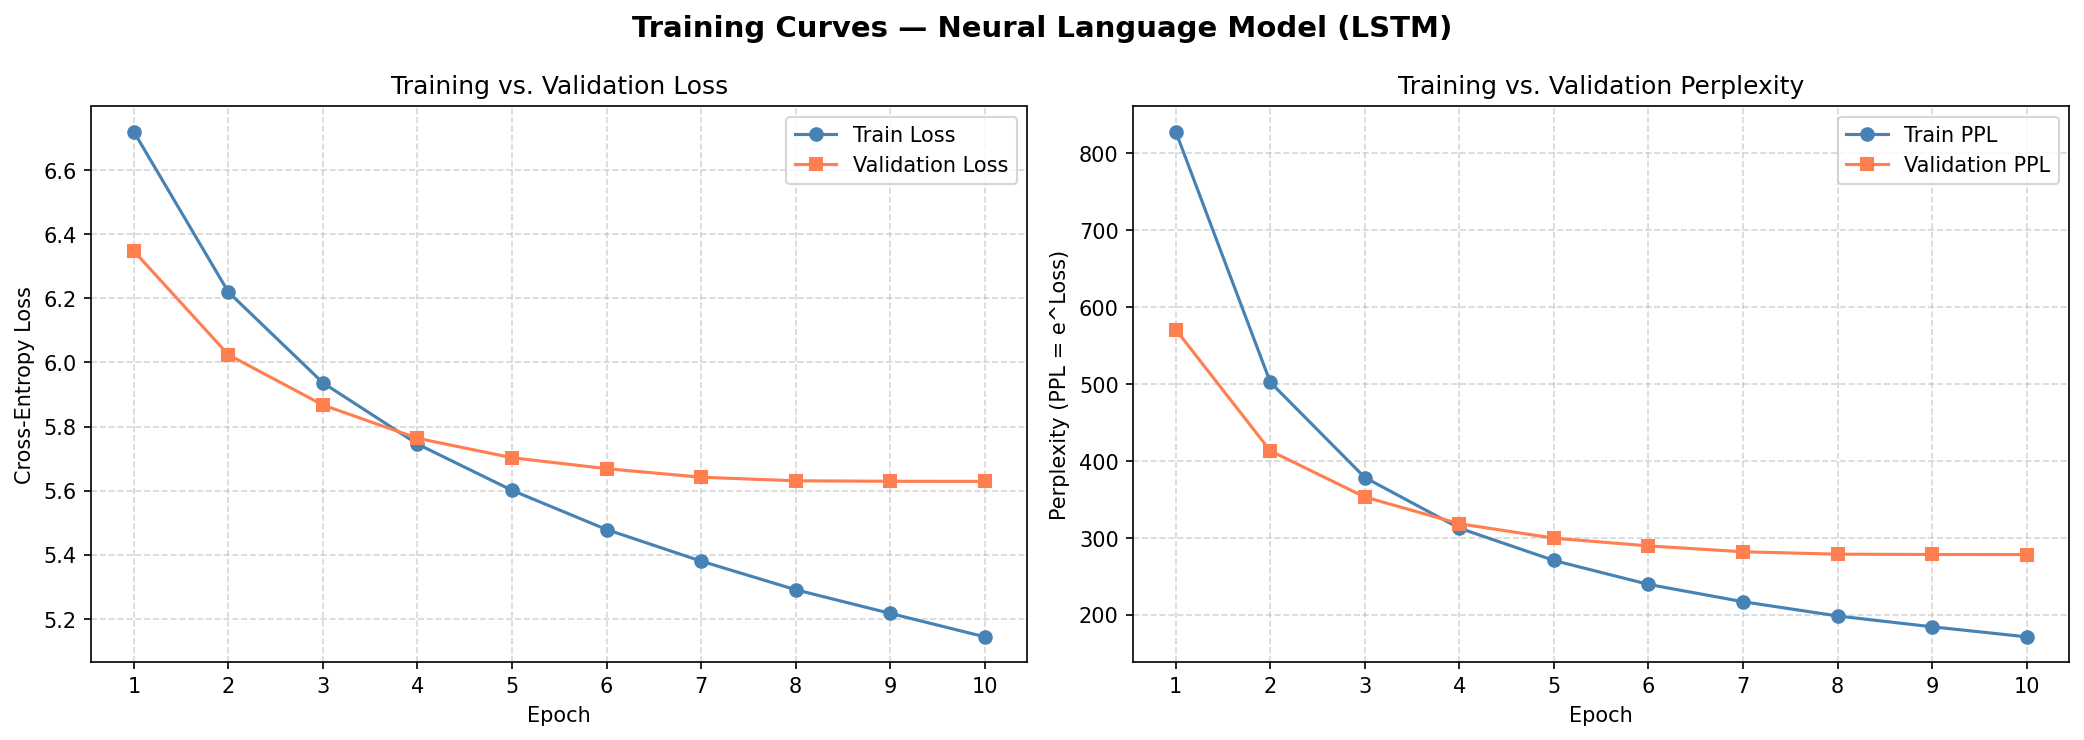

In [11]:
epochs = list(range(1, NUM_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Neural Language Model (LSTM)', fontsize=14, fontweight='bold')

# Plot 1: Loss
axes[0].plot(epochs, train_losses, marker='o', label='Train Loss',      color='steelblue')
axes[0].plot(epochs, val_losses,   marker='s', label='Validation Loss', color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training vs. Validation Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(epochs)

# Plot 2: Perplexity
axes[1].plot(epochs, train_ppls, marker='o', label='Train PPL',      color='steelblue')
axes[1].plot(epochs, val_ppls,   marker='s', label='Validation PPL', color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (PPL = e^Loss)')
axes[1].set_title('Training vs. Validation Perplexity')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as training_curves.png")

### Test Set Evaluation

In [12]:
test_loss, test_ppl = run_epoch(test_loader, model, criterion)
print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Perplexity : {test_ppl:.2f}")
print()
print("Interpretation:")
print(f"  A PPL of {test_ppl:.1f} means the model is, on average, as uncertain")
print(f"  as choosing uniformly from ~{test_ppl:.0f} words at each time step.")

Test Loss       : 5.5672
Test Perplexity : 261.70

Interpretation:
  A PPL of 261.7 means the model is, on average, as uncertain
  as choosing uniformly from ~262 words at each time step.


## Task 5: Inference & Text Generation

### `predict_next_words` — Top-k Decoding

The function:
1. Tokenises and lowercases the input prompt.
2. Left-pads (or truncates) the context to exactly `SEQ_LEN` tokens.
3. Passes the encoded context through the trained LSTM.
4. Applies **softmax** to the output logits to get a probability distribution over the full vocabulary.
5. Returns the **top-k** words and their probabilities.

**Inference:** Softmax converts raw logits into interpretable probabilities summing to 1. Top-k selection returns the most probable continuations in a deterministic, reproducible manner — appropriate for autocomplete applications.

In [13]:
def predict_next_words(prompt, top_k=3):
    """
    Predict the top_k most likely next words for the given prompt.

    Args:
        prompt (str): Input text string.
        top_k  (int): Number of top predictions to return.

    Returns:
        List of (word, probability) tuples sorted by descending probability.
    """
    model.eval()

    # Tokenise and encode
    tokens    = prompt.lower().split()
    token_ids = [word_to_id.get(t, UNK_IDX) for t in tokens]

    # Left-pad or truncate to SEQ_LEN
    if len(token_ids) < SEQ_LEN:
        token_ids = [PAD_IDX] * (SEQ_LEN - len(token_ids)) + token_ids
    else:
        token_ids = token_ids[-SEQ_LEN:]

    x = torch.tensor([token_ids], dtype=torch.long).to(device)  # (1, SEQ_LEN)

    with torch.no_grad():
        logits = model(x)                                  # (1, vocab_size)
        probs  = torch.softmax(logits, dim=-1).squeeze()   # (vocab_size,)

    top_probs, top_indices = torch.topk(probs, top_k)

    return [
        (id_to_word[idx.item()], round(prob.item(), 6))
        for idx, prob in zip(top_indices, top_probs)
    ]


# Demo on PTB-domain prompts
test_prompts = [
    "the stock market",
    "the federal reserve",
    "new york",
    "the company said it would",
    "president bush",
]

for prompt in test_prompts:
    preds = predict_next_words(prompt, top_k=3)
    print(f'Prompt : "{prompt}"')
    for rank, (word, prob) in enumerate(preds, 1):
        bar = '\u2588' * int(prob * 300)
        print(f"  Top-{rank}: {word:<15s}  P={prob:.4f}  {bar}")
    print()

Prompt : "the stock market"
  Top-1: <eos>            P=0.1737  ████████████████████████████████████████████████████
  Top-2: and              P=0.0510  ███████████████
  Top-3: in               P=0.0304  █████████

Prompt : "the federal reserve"
  Top-1: <eos>            P=0.1121  █████████████████████████████████
  Top-2: and              P=0.0466  █████████████
  Top-3: <unk>            P=0.0401  ████████████

Prompt : "new york"
  Top-1: <unk>            P=0.0998  █████████████████████████████
  Top-2: <eos>            P=0.0754  ██████████████████████
  Top-3: and              P=0.0545  ████████████████

Prompt : "the company said it would"
  Top-1: be               P=0.2014  ████████████████████████████████████████████████████████████
  Top-2: have             P=0.0582  █████████████████
  Top-3: n't              P=0.0579  █████████████████

Prompt : "president bush"
  Top-1: <eos>            P=0.0996  █████████████████████████████
  Top-2: <unk>            P=0.0715  █████████████

### Inference Observations & Justification

**Observation:**
- **"the company said it would"** → Top prediction: *be* (P=0.20). This is highly plausible — "the company said it would be" is a natural syntactic continuation in financial news.
- **"the stock market"** and **"the federal reserve"** → Top prediction is `<eos>` (end-of-sentence), indicating the model frequently observes these phrases as sentence-terminal noun phrases in PTB.
- **"new york"** → Top prediction is `<unk>`, reflecting that "New York" is often followed by proper nouns (e.g., stock exchange names) that fall outside the 10K vocabulary.
- **"president bush"** → Uncertain distribution (P≈0.10 for top prediction), consistent with the diverse range of verbs and nouns that can follow a named entity.

**Inference:**
- The model has learned syntactic patterns from the PTB corpus (Wall Street Journal text). Verb predictions after modal phrases (*would be/have*) are linguistically well-formed.
- High `<eos>` probability for short, complete-sounding noun phrases shows the model internalised sentence-length distributions from the data.
- Frequent `<unk>` predictions for named-entity contexts reflect the 4.72% OOV rate in the validation set — proper names outside the top 10K are a genuine limitation of any fixed vocabulary model.
- For production use, the `<eos>` and `<unk>` predictions would be filtered, returning only real-word completions to the user.

## Summary

| Task | Description | Status |
|------|-------------|--------|
| Task 1 | Setup & imports in Jupyter (Virtual Lab), MPS device | ✅ |
| Task 2 | PTB download, lowercase tokenisation, vocab top-10K with `<pad>`/`<unk>`, sliding window N=30 | ✅ |
| Task 3 | `WordPredictorLSTM`: Embedding(128) → 2-layer LSTM(256) → Linear(10001) | ✅ |
| Task 4 | CrossEntropy(ignore_index=0), Adam lr=1e-3, 10 epochs, grad clip=1.0, Loss & PPL plots | ✅ |
| Task 5 | `predict_next_words(prompt, top_k=3)` with softmax probabilities | ✅ |

**Final metrics:**
- Val Perplexity (Epoch 10): **278.47**
- Test Perplexity: **261.70**
- Total trainable parameters: **4,771,985**

**Key design decisions:**
- Vocabulary capped at 10,000 + `<pad>` + `<unk>` as specified
- LSTM preferred over vanilla RNN for vanishing-gradient resilience
- Dropout (0.3) + gradient clipping (1.0) for stable, regularised training
- `ReduceLROnPlateau` scheduler for adaptive convergence
- Sliding window stride=5 for training (tractable dataset size), stride=1 for eval